In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
torch.cuda.empty_cache()

In [3]:
import os
os.chdir('/home/stud/ath/ath_ws/keypoint_matcher')

from config import config
from utils import logger
from utils import show_batch

import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F

# torch.cuda.empty_cache()

# Check Data Module

In [4]:
from src import MatchesDataModule
dm = MatchesDataModule()

dm.setup(stage='fit')

INFO     | _get_names | Processing train
INFO     | _get_names | Processing all
INFO     | _get_names | Image Pair Counts : MGO07_mapping_easy cam0 : 1595
INFO     | _get_names | Image Pair Counts : MGO07_mapping_easy cam1 : 1595
INFO     | _get_names | Processing normal
INFO     | _get_names | Processing blur
INFO     | setup | Train Dataset       : 3190 samples
INFO     | _get_names | Processing val
INFO     | _get_names | Processing all
INFO     | _get_names | Image Pair Counts : MGO07_mapping_easy cam0 : 1595
INFO     | _get_names | Image Pair Counts : MGO07_mapping_easy cam1 : 1595
INFO     | _get_names | Processing normal
INFO     | _get_names | Processing blur
INFO     | setup | Validation Dataset  : 3190 samples


In [5]:
dl = dm.train_dataloader()

In [6]:
batch = next(iter(dl))

reference_patches = batch.reference_patches
target_patches = batch.target_patches
print(reference_patches.shape, target_patches.shape) 

patch_level_reference_coords = batch.patch_level_reference_coords
patch_level_target_coords = batch.patch_level_target_coords
print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

# rotations = batch.rotations
# print(rotations.shape)

torch.Size([229, 3, 32, 32]) torch.Size([229, 3, 32, 32])
torch.Size([229, 2]) torch.Size([229, 2])


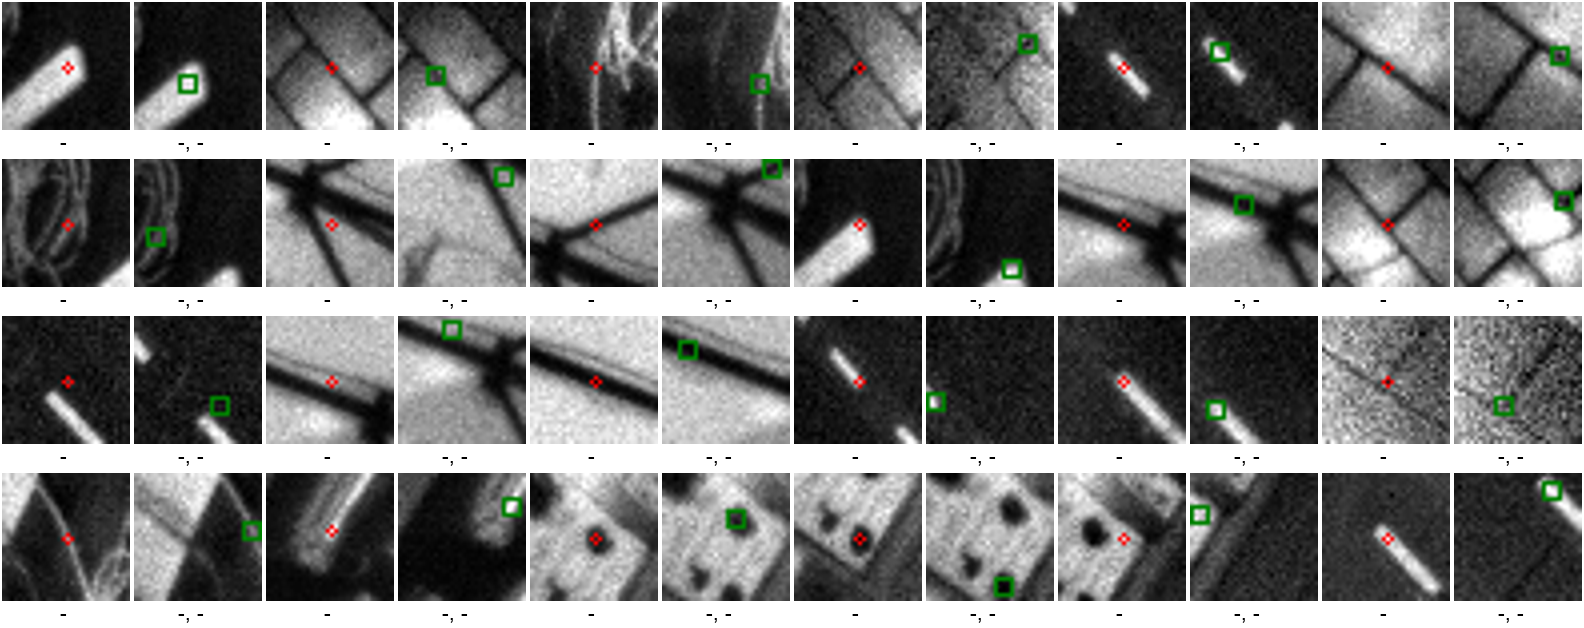

In [7]:
# batch = next(iter(dl))

# reference_patches = batch.reference_patches
# target_patches = batch.target_patches
# print(reference_patches.shape, target_patches.shape) 

# patch_level_reference_coords = batch.patch_level_reference_coords
# patch_level_target_coords = batch.patch_level_target_coords
# print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

# rotations = batch.rotations
# print(rotations.shape)

count = 24 * 1

# dont forget to comment out PNV

show_batch(
    reference_patches, target_patches,
    patch_level_reference_coords, patch_level_target_coords,
    patch_level_target_coords,
    # rotations_true=batch.rotations,
    # rotations=batch.rotations,
    limit_count=count, 
    n_columns=6,
    just_gt=True,
)

# Rotation Interpretation
# How to get reference patch using target patch?
# Positive = Anti-clockwise movement
# Negative = Clockwise movement

In [8]:
# print(patch_level_target_coords.shape)

# pred = torch.rand(90, 2) * 2 - 1
# print(pred.shape)

# target = patch_level_target_coords

# # Scale pred from [-1, 1] to [0, 31]
# scaled_pred = (pred.float() + 1) * 15.5 
# print(scaled_pred.shape)

# difference = torch.abs(target - target)
# print(difference.shape)

# # Check which differences exceed N pixels
# exceeds = (difference > 1).any(dim=1)
# print(exceeds.shape)

# # Calculate the percentage
# percentage = (exceeds.sum().item() / scaled_pred.shape[0]) * 100
# print(percentage)

In [9]:
# for index, batch in enumerate(dl):
#     print(f'-- Batch Index {index} -----')
#     reference_patches = batch.reference_patches
#     target_patches = batch.target_patches
#     print(reference_patches.shape, target_patches.shape) 

#     patch_level_reference_coords = batch.patch_level_reference_coords
#     patch_level_target_coords = batch.patch_level_target_coords
#     print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

#     rotations = batch.rotations
#     print(rotations.shape)

# Check Model

In [13]:
!export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

In [14]:
# torch.cuda.empty_cache()

from src import Light
light = Light()

from utils import count_params
num = count_params(light.model)
print(f"{num:,}")

1,816,899


In [ ]:
print('Model Inputs')
print(f'reference_patches shape : {reference_patches.shape}')
print(f'target_patches shape : {target_patches.shape}')
print(f'patch_level_reference_coords shape : {patch_level_reference_coords.shape}')

reference_patches, target_patches, patch_level_reference_coords = reference_patches.to('cuda'), target_patches.to('cuda'), patch_level_reference_coords.to('cuda')

print('Model Outputs')

# target_coords, target_confidence, target_rotation = light(
#     reference_patches, 
#     target_patches, 
#     patch_level_reference_coords
# )

target_coords, target_confidence = light(
    reference_patches, 
    target_patches, 
    patch_level_reference_coords
)

print(f'target_coords shape : {target_coords.shape}')
print(f'target_confidence shape : {target_confidence.shape}')
# print(f'target_rotation shape : {target_rotation.shape}')

Model Inputs
reference_patches shape : torch.Size([216, 3, 32, 32])
target_patches shape : torch.Size([216, 3, 32, 32])
patch_level_reference_coords shape : torch.Size([216, 2])
Model Outputs


OutOfMemoryError: CUDA out of memory. Tried to allocate 54.00 MiB. GPU 0 has a total capacity of 3.94 GiB of which 41.62 MiB is free. Including non-PyTorch memory, this process has 3.89 GiB memory in use. Of the allocated memory 3.73 GiB is allocated by PyTorch, and 108.61 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [30]:
# from torchinfo import summary

# summary(
#     light.model, 
#     input_data=[
#         reference_patches, 
#         target_patches, 
#         patch_level_reference_coords
#     ]
# )